## Importation des packages

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Importation des données
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Renommage des colonnes en français
df = df.rename(columns={
    'MedInc': 'Revenu_médian_quartier',
    'HouseAge': 'Âge_médian_maisons',
    'AveRooms': 'Pièces_moyennes_foyer',
    'AveBedrms': 'Chambres_moyennes_foyer',
    'Population': 'Population_quartier',
    'AveOccup': 'Taille_moyenne_ménage',
    'Latitude': 'Latitude',
    'Longitude': 'Longitude',
    'MedHouseVal': 'Prix_médian_maisons'  
})

In [5]:
df.head()

,Revenu_médian_quartier,Âge_médian_maisons,Pièces_moyennes_foyer,Chambres_moyennes_foyer,Population_quartier,Taille_moyenne_ménage,Latitude,Longitude,Prix_médian_maisons
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
#Valeurs manquantes

df.isnull().sum()

Revenu_médian_quartier     0
Âge_médian_maisons         0
Pièces_moyennes_foyer      0
Chambres_moyennes_foyer    0
Population_quartier        0
Taille_moyenne_ménage      0
Latitude                   0
Longitude                  0
Prix_médian_maisons        0
dtype: int64

## Analyse sur la base globale

In [7]:
# Résumé statistique des variables
df.describe()

,Revenu_médian_quartier,Âge_médian_maisons,Pièces_moyennes_foyer,Chambres_moyennes_foyer,Population_quartier,Taille_moyenne_ménage,Latitude,Longitude,Prix_médian_maisons
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


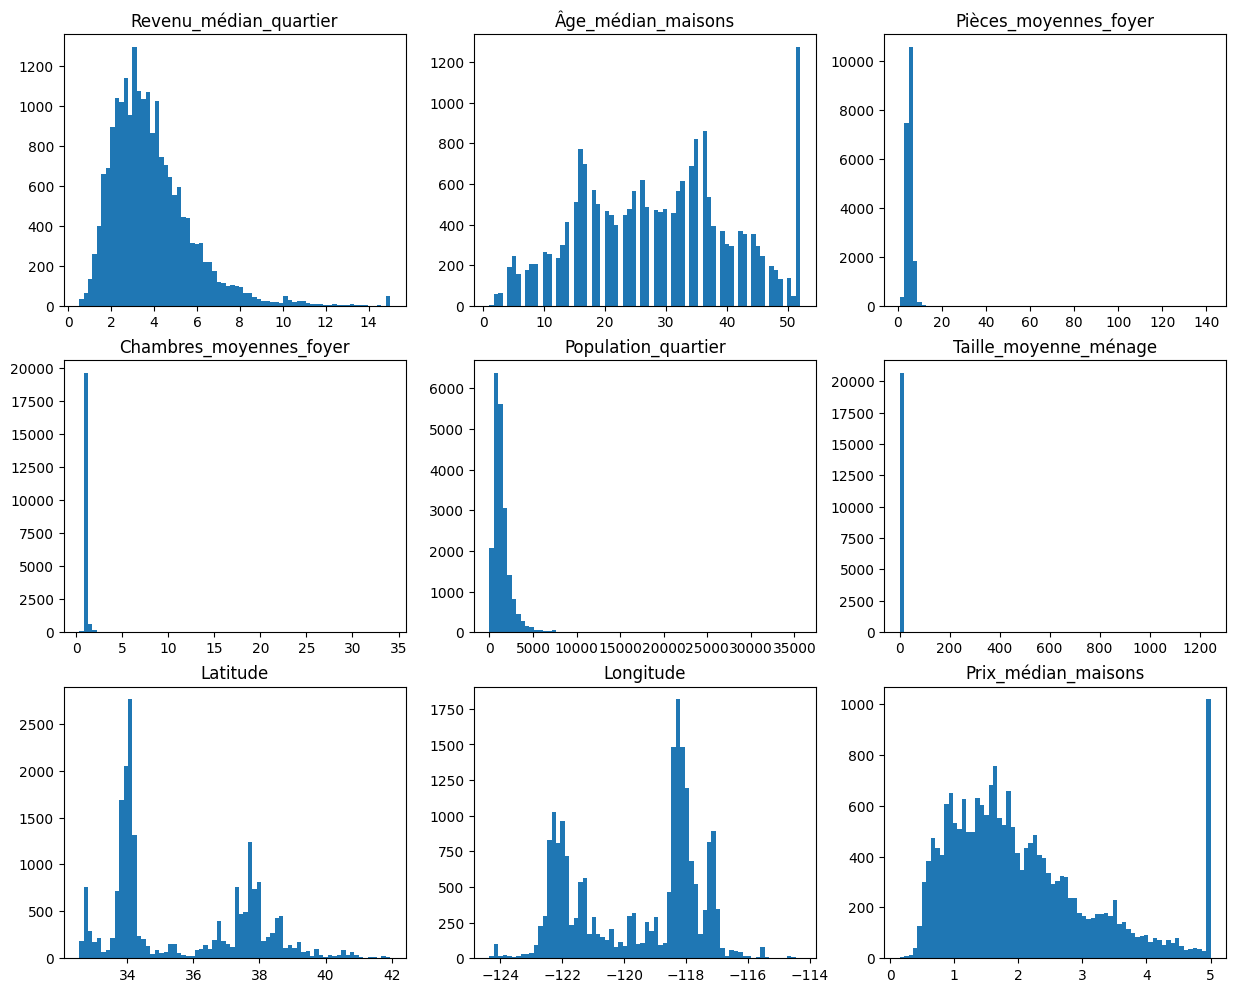

In [8]:
# Visualisation de la distribution des variables
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
axs = axs.ravel()

for i, column in enumerate(df.columns):
    axs[i].hist(df[column], bins=70)
    axs[i].set_title(column)

plt.show()

## Distribution des variables

In [9]:

import seaborn as sns

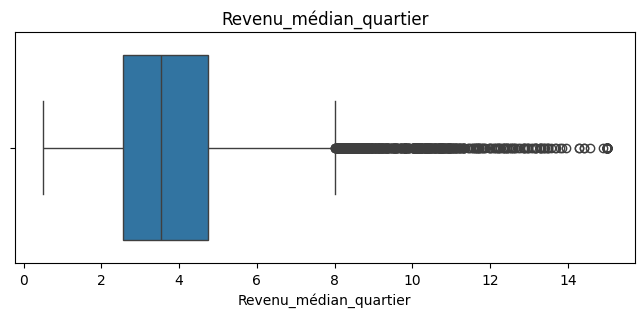

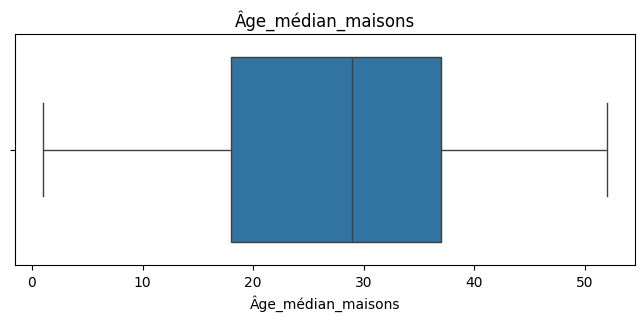

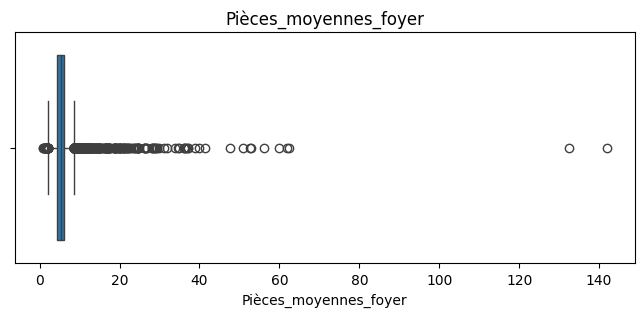

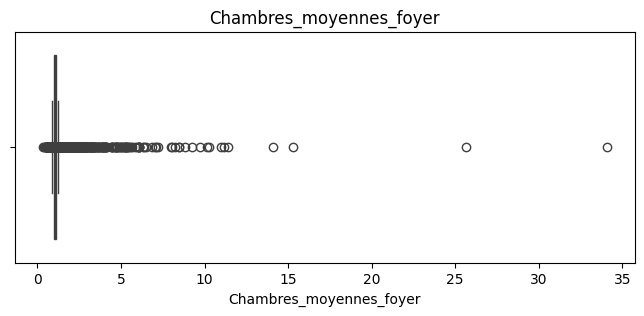

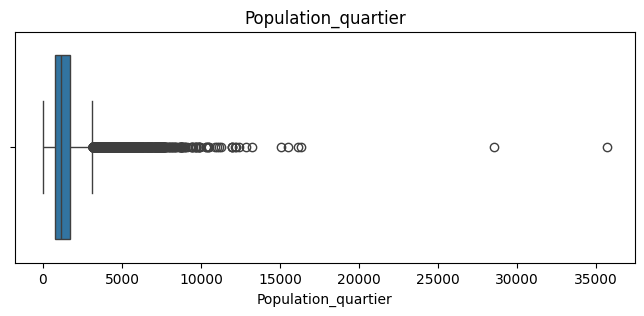

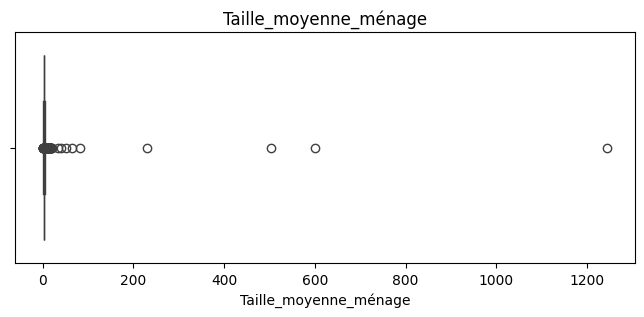

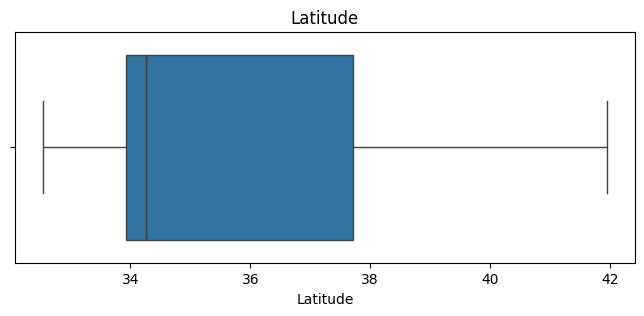

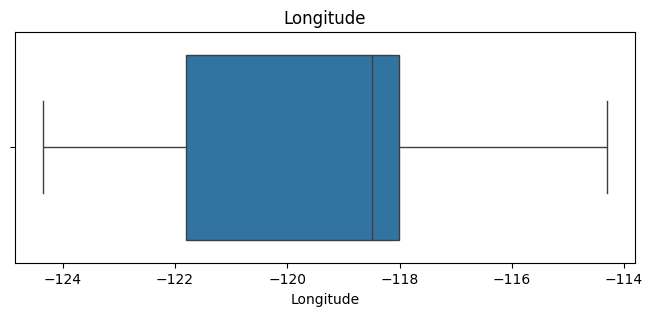

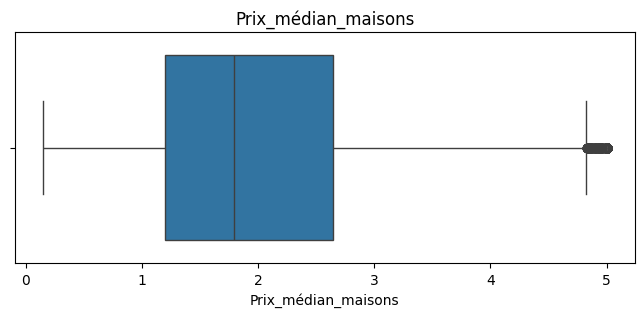

In [10]:
# Tracé des boxplots pour chaque variable
for column in df.columns:
    fig, ax = plt.subplots(figsize=(8, 3))
    sns.boxplot(x=df[column], ax=ax)
    plt.title(column)
    plt.show()

## Corrélation entre les variables

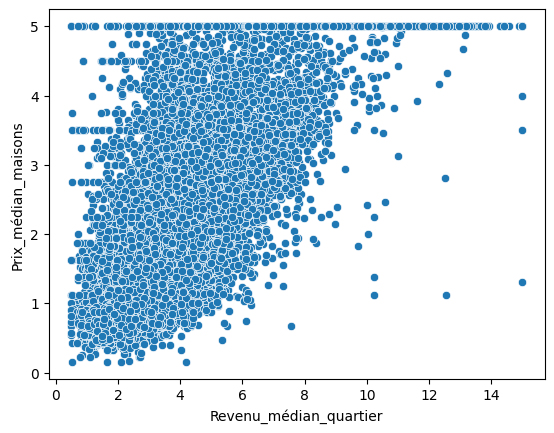

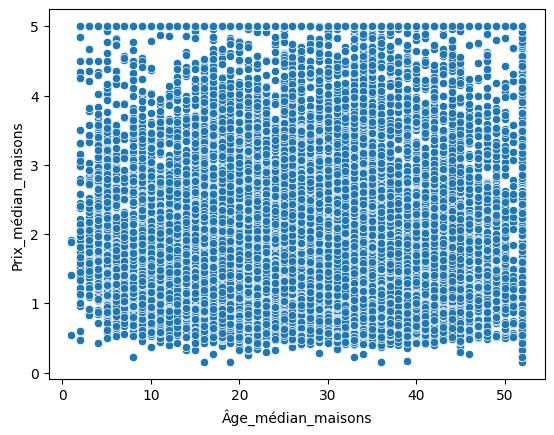

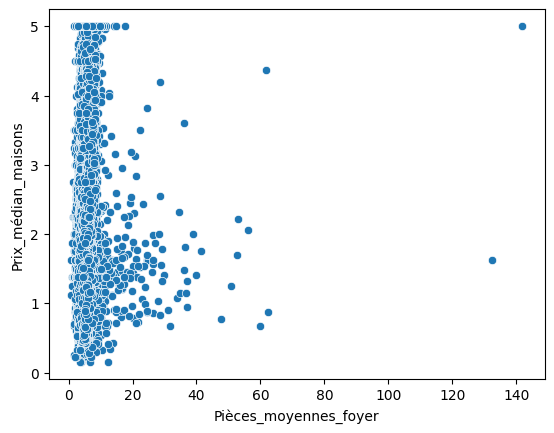

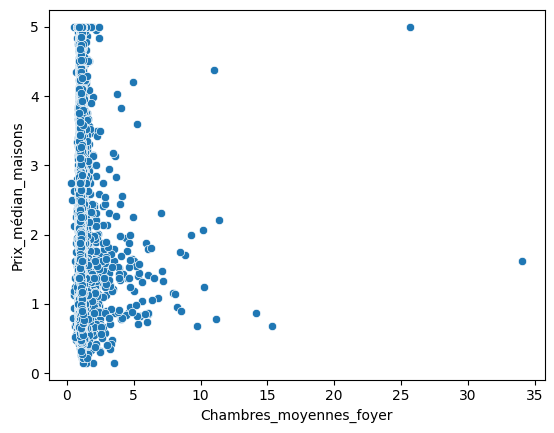

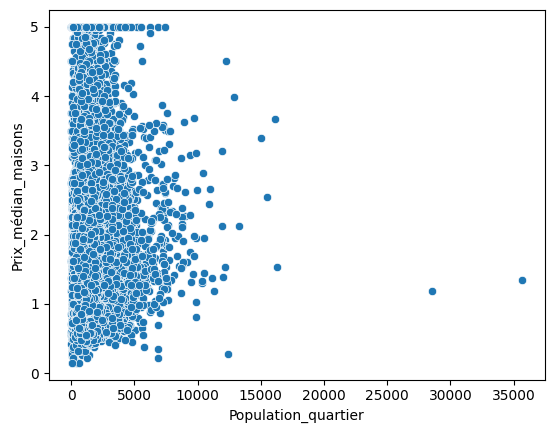

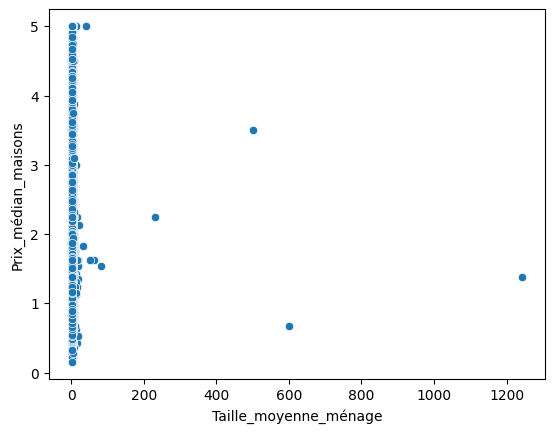

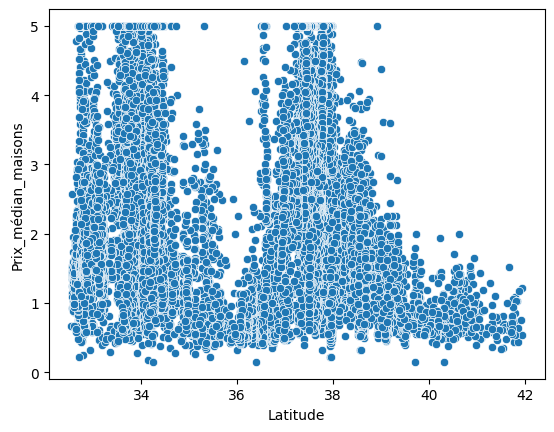

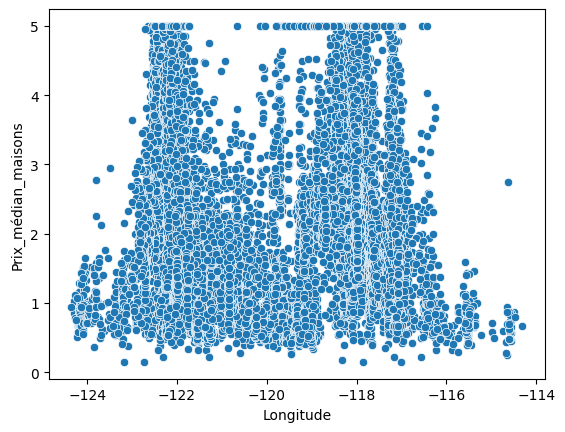

In [11]:
# Extraction des colonnes de variables explicatives
X = df.drop("Prix_médian_maisons", axis=1)

# Affichage des nuages de points entre la variable à expliquer et toutes les variables explicatives avec seaborn
for col in X.columns:
    sns.scatterplot(x=X[col], y=df["Prix_médian_maisons"])
    plt.show()

<Axes: >

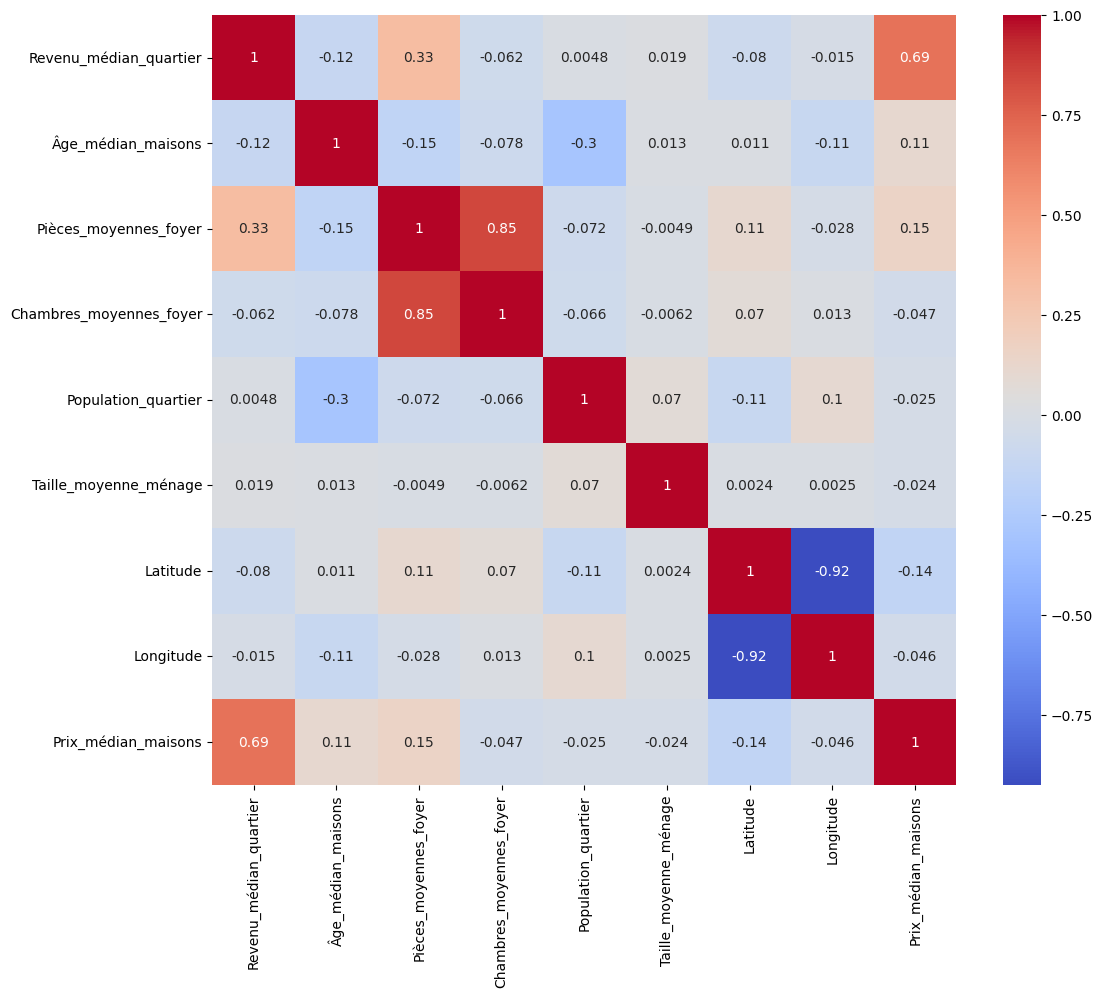

In [12]:
# Calcul de la matrice de corrélation
corr_matrix = df.corr()


plt.figure(figsize=(12, 10))
# Affichage de la matrice de corrélation sous forme de heatmap avec seaborn
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

## Division en Train et en Test

In [13]:
# Diviser les données en ensembles d'apprentissage et de test

train, test = train_test_split(df, test_size=0.2, random_state=42)

## Sélection des features sur la base train

In [14]:
# Résumé statistique des variables
train.describe()

,Revenu_médian_quartier,Âge_médian_maisons,Pièces_moyennes_foyer,Chambres_moyennes_foyer,Population_quartier,Taille_moyenne_ménage,Latitude,Longitude,Prix_médian_maisons
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290,2.071947
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654,1.156226
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000,1.198000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000,1.798500
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000,2.651250
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Modélisation sur la base train

In [15]:
!pip install statsmodels --upgrade

In [16]:

import statsmodels.api as sm
# Séparation des variables prédictives et de la variable cible
X_train = train.drop("Prix_médian_maisons", axis=1)
y_train = train["Prix_médian_maisons"]

# Fit du modèle linéaire
lr_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

In [17]:

y_train_pred = lr_model.predict(sm.add_constant(X_train))

## Vérification des hypothèses du modèles

# Vérification de l'homoscédasticité

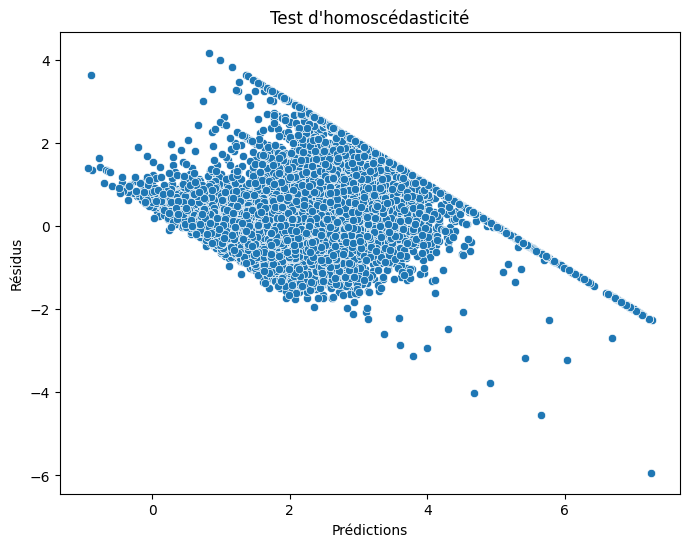

In [18]:
# Test d'homoscédasticité
y_train_pred = lr_model.predict(sm.add_constant(X_train))
residuals = y_train - y_train_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train_pred, y=residuals)
plt.title('Test d\'homoscédasticité')
plt.xlabel('Prédictions')
plt.ylabel('Résidus')
plt.show()

Le modèle ne vérifie pas l'homoscédacité 

# Transformation de y

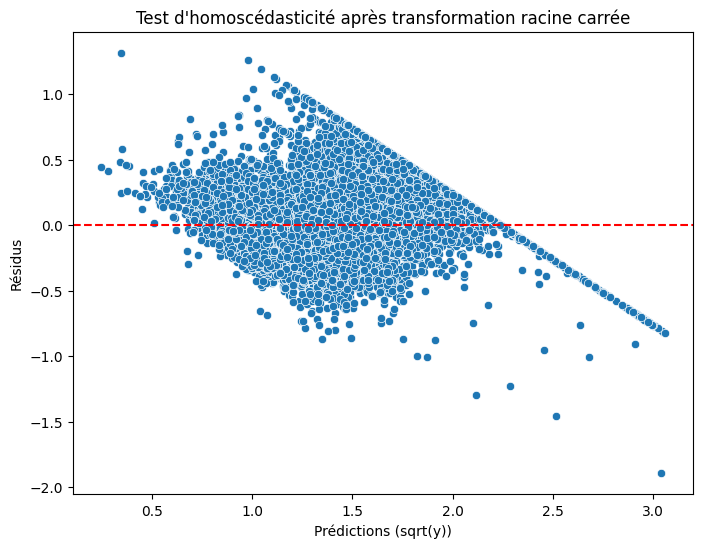

In [19]:
import numpy as np

y_train_sqrt = np.sqrt(y_train)
lr_model_sqrt = sm.OLS(y_train_sqrt, sm.add_constant(X_train)).fit()
y_train_sqrt_pred = lr_model_sqrt.predict(sm.add_constant(X_train))
residuals_sqrt = y_train_sqrt - y_train_sqrt_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train_sqrt_pred, y=residuals_sqrt)
plt.axhline(0, color='red', linestyle='--')
plt.title('Test d\'homoscédasticité après transformation racine carrée')
plt.xlabel("Prédictions (sqrt(y))")
plt.ylabel("Résidus")
plt.show()



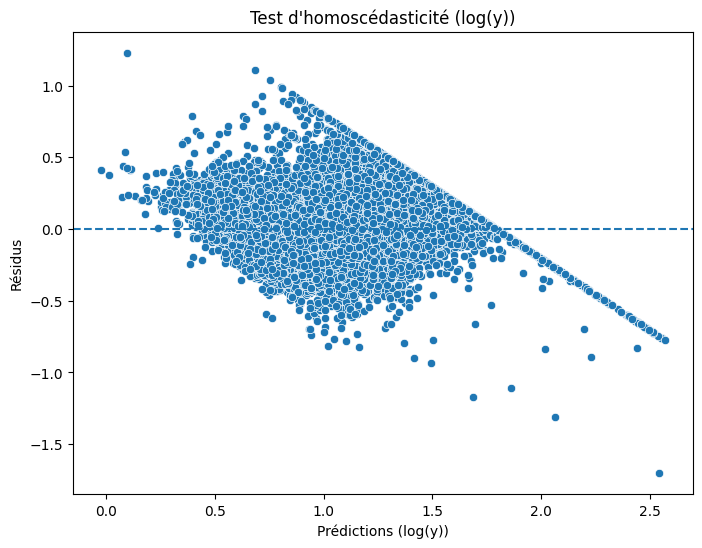

In [20]:
import numpy as np

y_train_log = np.log1p(y_train)
lr_model_log = sm.OLS(y_train_log, sm.add_constant(X_train)).fit()
y_train_log_pred = lr_model_log.predict(sm.add_constant(X_train))
residuals_log = y_train_log - y_train_log_pred      
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train_log_pred, y=residuals_log)
plt.axhline(0, linestyle='--')
plt.title("Test d'homoscédasticité (log(y))")
plt.xlabel("Prédictions (log(y))")
plt.ylabel("Résidus")
plt.show()



In [21]:
ols_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

y_train_pred = ols_model.predict(sm.add_constant(X_train))
residuals = y_train - y_train_pred

variance_est = residuals**2
weights = 1 / variance_est
weights = 1 / (variance_est + 1e-6)

wls_model = sm.WLS(
    y_train,
    sm.add_constant(X_train),
    weights=weights
).fit()
y_train_wls_pred = wls_model.predict(sm.add_constant(X_train))
residuals_wls = y_train - y_train_wls_pred



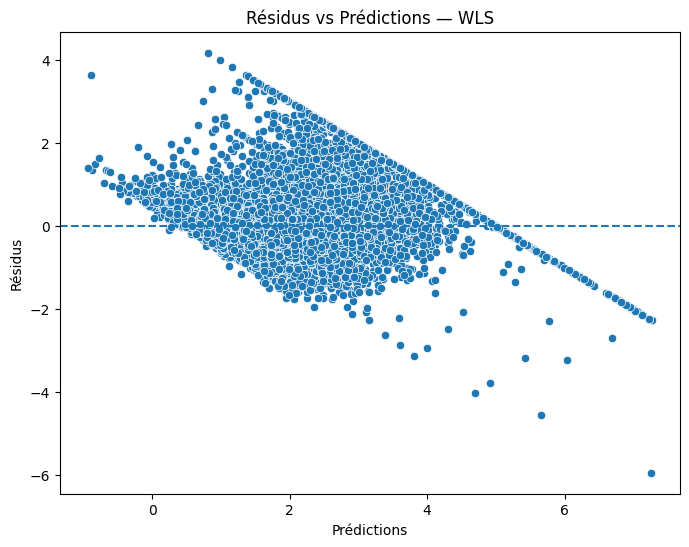

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train_wls_pred, y=residuals_wls)
plt.axhline(0, linestyle='--')
plt.title("Résidus vs Prédictions — WLS")
plt.xlabel("Prédictions")
plt.ylabel("Résidus")
plt.show()


Après avoir essayé la méthode des moindres carrés ci-dessus , on se rend compte que le modèle demeure hétéroscédsticite.
Le modèle n'est pas le plus approprié.

# Vérification de la multicolinéarité

In [23]:

# Test de multicollinéarité
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif["features"] = X_train.columns
print(vif)

   VIF Factor                 features
0   11.831609   Revenu_médian_quartier
1    7.155405       Âge_médian_maisons
2   46.792373    Pièces_moyennes_foyer
3   48.332634  Chambres_moyennes_foyer
4    2.915730      Population_quartier
5    1.080609    Taille_moyenne_ménage
6  560.583263                 Latitude
7  641.224254                Longitude


In [24]:

train.columns

Index(['Revenu_médian_quartier', 'Âge_médian_maisons', 'Pièces_moyennes_foyer',
       'Chambres_moyennes_foyer', 'Population_quartier',
       'Taille_moyenne_ménage', 'Latitude', 'Longitude',
       'Prix_médian_maisons'],
      dtype='object')

In [25]:
import pandas as pd

# X sous forme DataFrame
X_df = pd.DataFrame(X_train)


# y sous forme Series
y_series = pd.Series(y_train, name="target")

# Corrélations (Pearson)
correlations = X_df.corrwith(y_series).abs().sort_values(ascending=False)


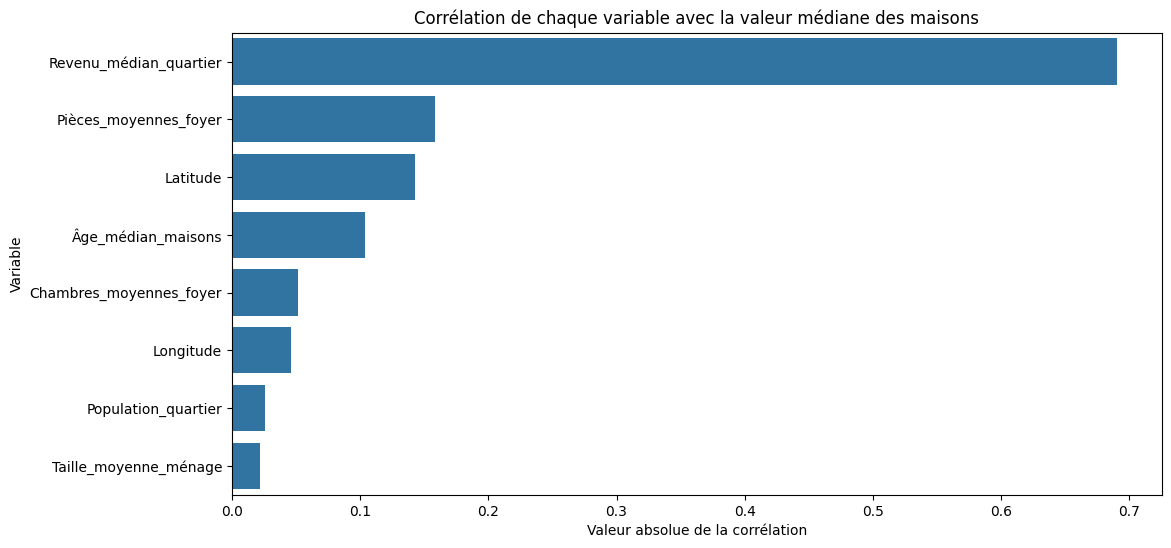

In [26]:
# Représentation graphique des corrélations
plt.figure(figsize=(12, 6))
sns.barplot(x=correlations.values, y=correlations.index)
plt.xlabel("Valeur absolue de la corrélation")
plt.ylabel("Variable")
plt.title("Corrélation de chaque variable avec la valeur médiane des maisons")
plt.show()

In [27]:
new_selection=['Taille_moyenne_ménage', 'Population_quartier','Âge_médian_maisons']
train_selectedb = train[new_selection]
train_selectedb["Prix_médian_maisons"] = train["Prix_médian_maisons"]
train_selectedb

C:\Users\afagn\AppData\Local\Temp\ipykernel_23080\2672883897.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_selectedb["Prix_médian_maisons"] = train["Prix_médian_maisons"]


,Taille_moyenne_ménage,Population_quartier,Âge_médian_maisons,Prix_médian_maisons
14196,3.691814,2300.0,33.0,1.030
8267,1.738095,1314.0,49.0,3.821
17445,2.723214,915.0,4.0,1.726
14265,3.994366,1418.0,36.0,0.934
2271,2.300000,874.0,43.0,0.965
...,...,...,...,...
11284,3.032258,658.0,35.0,2.292
11964,3.904232,1753.0,33.0,0.978
5390,3.332068,1756.0,36.0,2.221
860,3.178891,1777.0,15.0,2.835


In [28]:
import statsmodels.api as sm
# Séparation des variables prédictives et de la variable cible
X_train = train_selectedb.drop("Prix_médian_maisons", axis=1)
y_train = train_selectedb["Prix_médian_maisons"]

# Fit du modèle linéaire
lr_modelb = sm.OLS(y_train, sm.add_constant(X_train)).fit()

In [29]:

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif["features"] = X_train.columns
print(vif)

   VIF Factor               features
0    1.078330  Taille_moyenne_ménage
1    1.726937    Population_quartier
2    1.724413     Âge_médian_maisons


In [30]:
import statsmodels.api as sm
# Séparation des variables prédictives et de la variable cible
X_train = train.drop("Prix_médian_maisons", axis=1)
y_train = train["Prix_médian_maisons"]

# Fit du modèle linéaire
lr_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# Obtention du tableau de résultats
results_table = lr_model.summary2().tables[1]
results_table

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,-37.023278,0.728303,-50.835014,0.000000e+00,-38.450829,-35.595726
Revenu_médian_quartier,0.448675,0.004689,95.696528,0.000000e+00,0.439485,0.457865
Âge_médian_maisons,0.009724,0.000494,19.665298,4.026550e-85,0.008755,0.010694
Pièces_moyennes_foyer,-0.123323,0.006603,-18.677144,4.728144e-77,-0.136266,-0.110381
Chambres_moyennes_foyer,0.783145,0.033246,23.556034,1.060451e-120,0.717979,0.848311
Population_quartier,-0.000002,0.000005,-0.386691,6.989900e-01,-0.000012,0.000008
Taille_moyenne_ménage,-0.003526,0.000486,-7.252892,4.260635e-13,-0.004479,-0.002573
Latitude,-0.419792,0.007956,-52.767191,0.000000e+00,-0.435386,-0.404199
Longitude,-0.433708,0.008322,-52.116663,0.000000e+00,-0.450020,-0.417396


## Vérification de la normalité

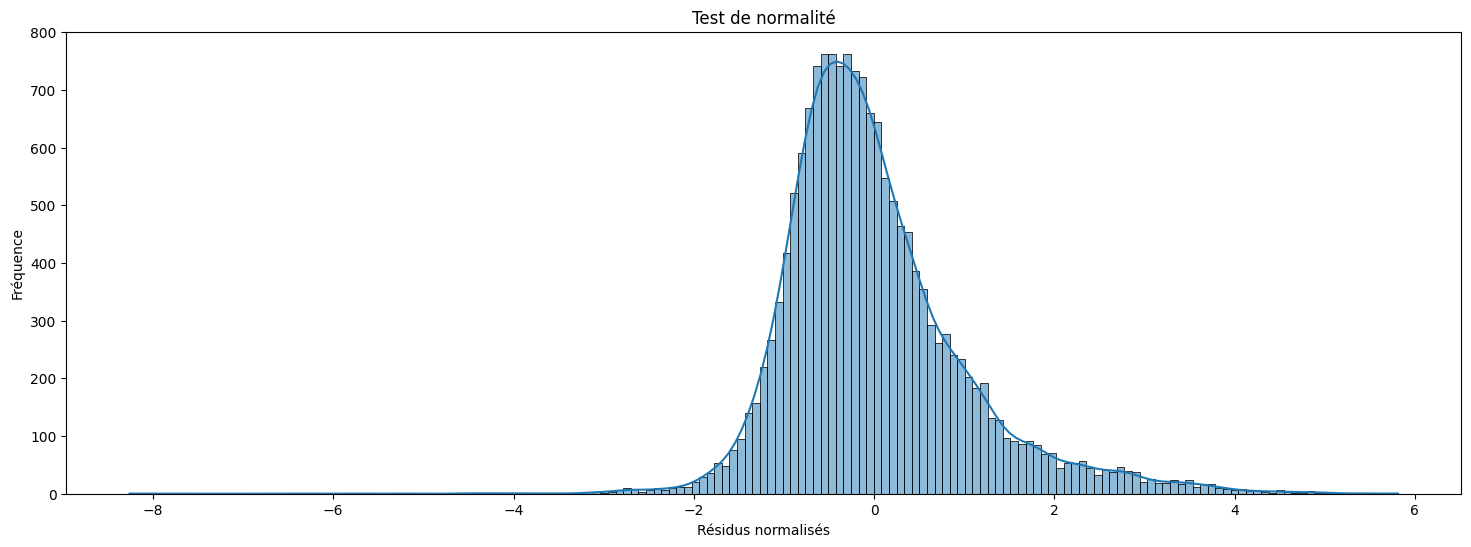

In [31]:

# Test de normalité
resid_norm = lr_model.get_influence().resid_studentized_internal
plt.figure(figsize=(18, 6))
sns.histplot(resid_norm, kde=True)
plt.title('Test de normalité')
plt.xlabel('Résidus normalisés')
plt.ylabel('Fréquence')
plt.show()

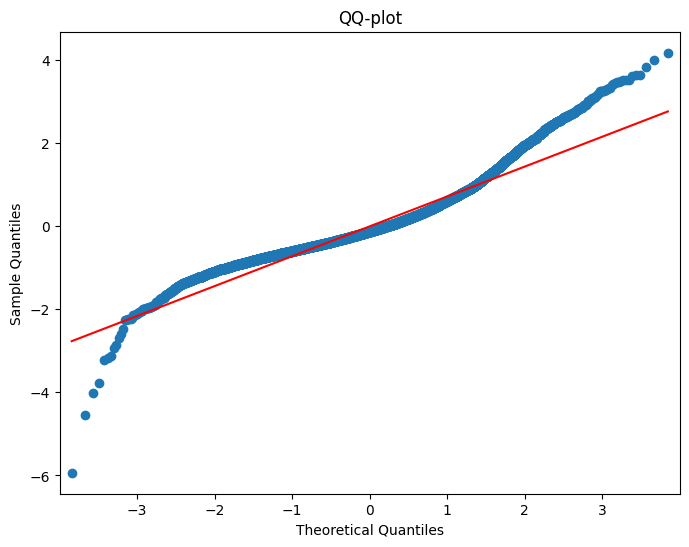

In [32]:
# QQ-plot
fig, ax = plt.subplots(figsize=(8, 6))
sm.qqplot(residuals, line='s', ax=ax)
ax.set_title('QQ-plot')
plt.show()

Les hypothèses de linéarité et de  normalité ne sont pas linéaire.

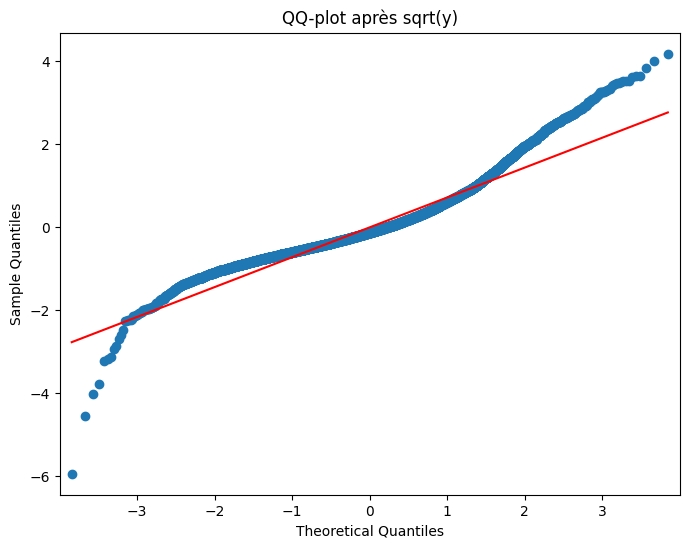

In [33]:
import numpy as np

y_train_sqrt = np.sqrt(y_train)
lr_model_sqrt = sm.OLS(y_train_sqrt, sm.add_constant(X_train)).fit()
y_train_sqrt_pred = lr_model_sqrt.predict(sm.add_constant(X_train))
residuals_sqrt = y_train_sqrt - y_train_sqrt_pred
fig, ax = plt.subplots(figsize=(8, 6))
sm.qqplot(residuals, line='s', ax=ax)
ax.set_title('QQ-plot après sqrt(y)')
plt.show()


La linéarité n'est donc pas vérifiée au niveau de ce modèle.

## Vérification de l'autocorrélation

In [34]:

from statsmodels.stats.stattools import durbin_watson
# Test d'autocorrélation
dw_test = durbin_watson(lr_model.resid)
print("Test de Durbin-Watson : statistique = %f" % dw_test)

Test de Durbin-Watson : statistique = 1.961793


## On conclut que les erreurs du modèle ne sont pas auto-corrélées. Cette hypothèse est donc vérifiée.

In [35]:
# Préparation des données de test
X_test = test.drop("Prix_médian_maisons", axis=1)   
y_test = test["Prix_médian_maisons"]
y_test_pred = lr_model.predict(sm.add_constant(X_test))



In [36]:
# Evaluation du modèle sur l'ensemble d'entrainement
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
print("Entraînement - MSE: %.4f, MAE: %.4f, R2: %.4f" % (mse_train, mae_train, r2_train))



Entraînement - MSE: 0.5179, MAE: 0.5286, R2: 0.6126


In [37]:
# Evaluation sur l'ensemble de test
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print("Test - MSE: %.4f, MAE: %.4f, R2: %.4f" % (mse_test, mae_test, r2_test))

Test - MSE: 0.5559, MAE: 0.5332, R2: 0.5758


## RANSAC (Robust Regression)

In [38]:
from sklearn.linear_model import RANSACRegressor

In [ ]:
ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=0.3,          # % min de données pour un fit initial
    residual_threshold=6.0,   # distance max pour être inlier (adapte selon scale)
    max_trials=400,
    stop_probability = 0.99,
    random_state=42
)
ransac.fit(X_train, y_train)

RANSACRegressor(estimator=LinearRegression(), max_trials=400, min_samples=0.3,
                random_state=41, residual_threshold=6.0)

In [73]:
inlier_mask = ransac.inlier_mask_
print(f"Nombre d'inliers: {inlier_mask.sum()} / {len(y_train)} ({inlier_mask.mean()*100:.1f}%)")

Nombre d'inliers: 16512 / 16512 (100.0%)


In [74]:
# Prédictions RANSAC
y_test_pred_ransac = ransac.predict(X_test)

mse_ransac   = mean_squared_error(y_test, y_test_pred_ransac)
mae_ransac   = mean_absolute_error(y_test, y_test_pred_ransac)
r2_ransac    = r2_score(y_test, y_test_pred_ransac)

print("RANSAC → MSE: %.4f, MAE: %.4f, R²: %.4f" % (mse_ransac, mae_ransac, r2_ransac))

RANSAC → MSE: 0.5559, MAE: 0.5332, R²: 0.5758
